In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

%matplotlib inline
%config InlineBackend.figure_format = 'retina'


In [3]:
DATA_DIR = Path("EGU_spatial_rmse")  # relative to this notebook in verification/
EXTENT   = [-17, 16, 40, 66]         # [lon_min, lon_max, lat_min, lat_max]
CMAP     = "YlOrRd"
NROWS, NCOLS = 2, 4

FILES = [
    # --- ws10 row ---
    ("spatial_rmse_ws10_NoPowerGT.nc",       "ws10 | NoPower | GT"),
    ("spatial_rmse_ws10_NoPowerTF.nc",       "ws10 | NoPower | TF"),
    ("spatial_rmse_ws10_VanillaPowerGT.nc",  "ws10 | VanillaPower | GT"),
    ("spatial_rmse_ws10_VanillaPowerTF.nc",  "ws10 | VanillaPower | TF"),
    # --- ws100 row ---
    ("spatial_rmse_ws100_NoPowerGT.nc",      "ws100 | NoPower | GT"),
    ("spatial_rmse_ws100_NoPowerTF.nc",      "ws100 | NoPower | TF"),
    ("spatial_rmse_ws100_VanillaPowerGT.nc", "ws100 | VanillaPower | GT"),
    ("spatial_rmse_ws100_VanillaPowerTF.nc", "ws100 | VanillaPower | TF"),
]

In [7]:
# Store full (lead_time, cell) arrays — we'll slice later
all_rmse, all_lats, all_lons, all_titles = [], [], [], []
lead_times = None

for fname, title in FILES:
    ds = xr.open_dataset(DATA_DIR / fname)
    all_rmse.append(ds["rmse"].values)          # (lead_time, cell)
    all_lats.append(ds["latitude"].values)
    all_lons.append(ds["longitude"].values)
    all_titles.append(title)
    if lead_times is None:
        lead_times = ds["lead_time"].values     # e.g. [0,3,6,...,36]
    ds.close()

print(f"Lead times available: {lead_times} h")

Lead times available: [ 0  3  6  9 12 15 18 21 24 27 30 33 36] h


In [ ]:
def robust_range(arrays):
    combined = np.concatenate(arrays)
    return np.nanpercentile(combined, 2), np.nanpercentile(combined, 98)


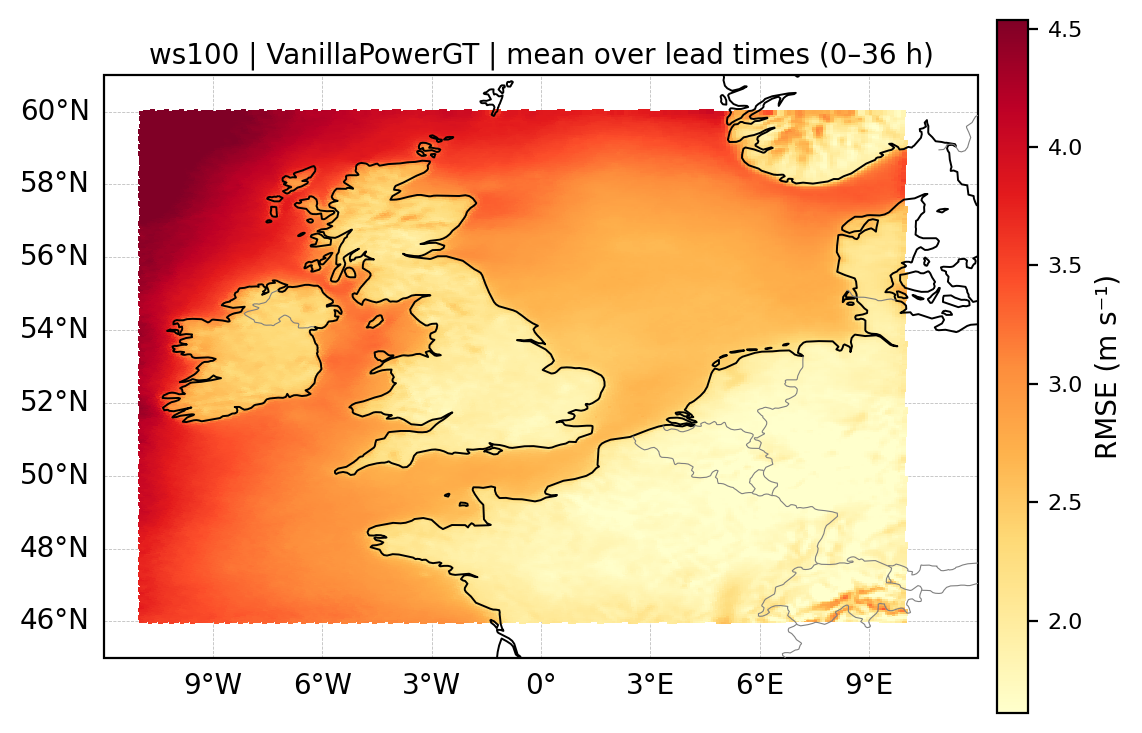

In [24]:
# ── CHOOSE HERE ───────────────────────────────────────────────────────────────
VARIABLE   = "ws100"          # "ws10" or "ws100"
MODEL      = "VanillaPowerGT"     # "NoPowerGT", "NoPowerTF", "VanillaPowerGT", "VanillaPowerTF"
MODE       = "mean"          # "mean" or "leadtime"
LEAD_TIME_H = 12             # only used when MODE = "leadtime"; one of 0,3,6,...,36
# ─────────────────────────────────────────────────────────────────────────────

EXTENT_TIGHT = [-12, 12, 45, 61]

# Find the right dataset
idx = next(i for i, (f, _) in enumerate(FILES) if MODEL in f and VARIABLE in f)

if MODE == "mean":
    field = all_rmse[idx].mean(axis=0)
    label = "mean over lead times (0–36 h)"
else:
    lt_idx = list(lead_times).index(LEAD_TIME_H)
    field  = all_rmse[idx][lt_idx]
    label  = f"lead time = {LEAD_TIME_H} h"

# Shared colour scale: same variable, all models
same_var_fields = [all_rmse[i].mean(axis=0) if MODE == "mean" else all_rmse[i][lt_idx]
                   for i, (f, _) in enumerate(FILES) if VARIABLE in f]
vmin, vmax = robust_range(same_var_fields)

# Plot
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(6, 5), subplot_kw={"projection": proj})
ax.set_extent(EXTENT_TIGHT, crs=proj)
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.7, edgecolor="black", zorder=3)
ax.add_feature(cfeature.BORDERS.with_scale("50m"),   linewidth=0.4, edgecolor="grey",  zorder=3)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="grey", alpha=0.5, linestyle="--")
gl.top_labels   = False
gl.right_labels = False

sc = ax.scatter(
    all_lons[idx], all_lats[idx], c=field,
    cmap=CMAP, vmin=vmin, vmax=vmax,
    s=3, marker="s", linewidths=0,
    transform=proj, rasterized=True, zorder=2,
)
fig.colorbar(sc, ax=ax, fraction=0.04, pad=0.02, shrink=0.9, aspect=22,
             label="RMSE (m s⁻¹)").ax.tick_params(labelsize=8)
ax.set_title(f"{VARIABLE} | {MODEL} | {label}", fontsize=10, pad=4)

save_path = DATA_DIR / f"spatial_rmse_{VARIABLE}_{MODEL}_{MODE if MODE == 'mean' else f'lt{LEAD_TIME_H:02d}h'}.png"
#plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()